# Inferencing with Pretrained Model

### Installation of Packages

In [ ]:
# Install TFOD2 and Dependencies
!git clone https://github.com/tensorflow/models.git
%cd models/research
!protoc object_detection/protos/*.proto --python_out=.
!cp object_detection/packages/tf2/setup.py .
!pip install .
!pip install tf-models-official

Cloning into 'models'...
remote: Enumerating objects: 102123, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 102123 (delta 181), reused 138 (delta 129), pack-reused 101842 (from 2)
Receiving objects: 100% (102123/102123), 629.39 MiB | 27.65 MiB/s, done.
Resolving deltas: 100% (72774/72774), done.
/content/models/research
Processing /content/models/research
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install protobuf==3.20.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.19.0 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.0 requires grpcio>=1.71.0, but you have grpcio 1.65.5 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
from object_detection.utils import label_map_util, visualization_utils as viz_utils

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
from matplotlib import pyplot as plt

%matplotlib inline

In [ ]:
#http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8.tar.gz

In [ ]:
# Download a pretrained Model
model_name = "faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8"
!wget http://download.tensorflow.org/models/object_detection/tf2/20200711/{model_name}.tar.gz
!tar -xvf {model_name}.tar.gz

--2025-06-30 06:42:18--  http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 142.250.31.207, 142.251.111.207, 142.251.167.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.250.31.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353893393 (337M) [application/x-tar]
Saving to: ‘faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8.tar.gz’

faster_rcnn_resnet1 100%[===================>] 337.50M  27.5MB/s    in 7.1s    

2025-06-30 06:42:25 (47.2 MB/s) - ‘faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8.tar.gz’ saved [353893393/353893393]

faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8/
faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8/checkpoint/
faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8/checkpoint/ckpt-0.data-00000-of-00001
faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8/checkpoint/checkpoint
faster_rcnn

In [ ]:
# 1. Use pretrained model path
PATH_TO_SAVED_MODEL = "faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8/saved_model"

In [ ]:
# 2. Load model
detect_fn = tf.saved_model.load(PATH_TO_SAVED_MODEL)

In [ ]:
!cat /content/models/research/object_detection/data/mscoco_label_map.pbtxt

item {
  name: "/m/01g317"
  id: 1
  display_name: "person"
}
item {
  name: "/m/0199g"
  id: 2
  display_name: "bicycle"
}
item {
  name: "/m/0k4j"
  id: 3
  display_name: "car"
}
item {
  name: "/m/04_sv"
  id: 4
  display_name: "motorcycle"
}
item {
  name: "/m/05czz6l"
  id: 5
  display_name: "airplane"
}
item {
  name: "/m/01bjv"
  id: 6
  display_name: "bus"
}
item {
  name: "/m/07jdr"
  id: 7
  display_name: "train"
}
item {
  name: "/m/07r04"
  id: 8
  display_name: "truck"
}
item {
  name: "/m/019jd"
  id: 9
  display_name: "boat"
}
item {
  name: "/m/015qff"
  id: 10
  display_name: "traffic light"
}
item {
  name: "/m/01pns0"
  id: 11
  display_name: "fire hydrant"
}
item {
  name: "/m/02pv19"
  id: 13
  display_name: "stop sign"
}
item {
  name: "/m/015qbp"
  id: 14
  display_name: "parking meter"
}
item {
  name: "/m/0cvnqh"
  id: 15
  display_name: "bench"
}
item {
  name: "/m/015p6"
  id: 16
  display_name: "bird"
}
item {
  name: "/m/01yrx"
  id: 17
  display_name: "cat

In [ ]:
# 3. Use COCO label map (download and place it if needed)
category_index = label_map_util.create_category_index_from_labelmap(
    "/content/models/research/object_detection/data/mscoco_label_map.pbtxt", use_display_name=True
)

In [ ]:
import requests
import os

def download_image(url, filename):
  """Downloads an image from a given URL and saves it to a file using requests.

  Args:
    url: The URL of the image.
    filename: The name of the file to save the image to.
  """
  try:
    # Add a User-Agent header to mimic a browser request
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36'
    }
    response = requests.get(url, headers=headers, stream=True)
    response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

    with open(filename, 'wb') as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            out_file.write(chunk)

    print(f"Image downloaded successfully to {filename}")
  except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")

# Now call the modified download_image function
download_image("https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg", "pexels-photo-13872248.jpg")



Image downloaded successfully to pexels-photo-13872248.jpg


In [ ]:
# Read and display the image
import cv2
from google.colab.patches import cv2_imshow

im = cv2.imread("/content/pexels-photo-13872248.jpg")
if im is not None:
    cv2_imshow(im)
else:
    print("Error: Could not read the image file.")

In [ ]:
# 4. Test image path
image_path = "/content/pexels-photo-13872248.jpg"
image_np = cv2.imread(image_path)

In [ ]:
# 5. Inference
input_tensor = tf.convert_to_tensor([image_np], dtype=tf.uint8)

detections = detect_fn(input_tensor)

In [ ]:
detections

{'detection_anchor_indices': <tf.Tensor: shape=(1, 300), dtype=float32, numpy=
 array([[  0.,   1., 100.,  17.,   8.,  50.,  79., 218.,  39., 104., 160.,
         204., 188., 292.,  12.,  83., 187., 124., 145., 266.,  49.,  25.,
         188.,  98.,  98.,  63., 299.,  31., 182.,  74., 153., 230., 182.,
         213., 172., 133., 124., 160., 165., 298., 150., 127.,  63.,  67.,
          18., 267., 190.,  18., 281.,  98., 237.,  39., 119.,  18., 183.,
          21., 295., 239., 230., 133., 262.,  31., 276., 254., 181., 224.,
          96., 213.,  42., 158., 198., 171., 188.,   6.,  39., 131., 159.,
          30., 192., 217., 170.,  77., 213., 213., 239., 165., 206., 197.,
         179., 170., 108., 219., 273., 170., 257., 230., 234., 271., 210.,
         181., 166., 223.,  86.,  25., 209., 157., 104., 297., 145., 253.,
          37., 182., 273., 230.,  39., 161., 193.,  39., 205., 197., 104.,
         195., 275., 205., 238., 140., 170., 277., 155., 226., 156.,  72.,
         177., 120., 

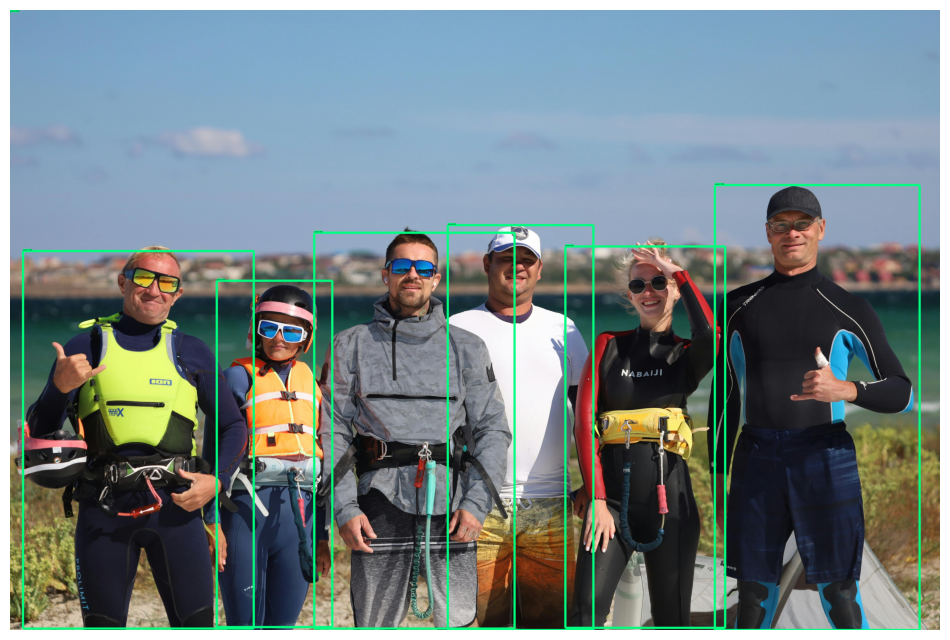

In [ ]:
# 6. Visualization
viz_utils.visualize_boxes_and_labels_on_image_array(
    image_np,
    detections['detection_boxes'][0].numpy(),
    detections['detection_classes'][0].numpy().astype(np.int32),
    detections['detection_scores'][0].numpy(),
    category_index,
    use_normalized_coordinates=False,
    line_thickness=15
)
# 7. Show image
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

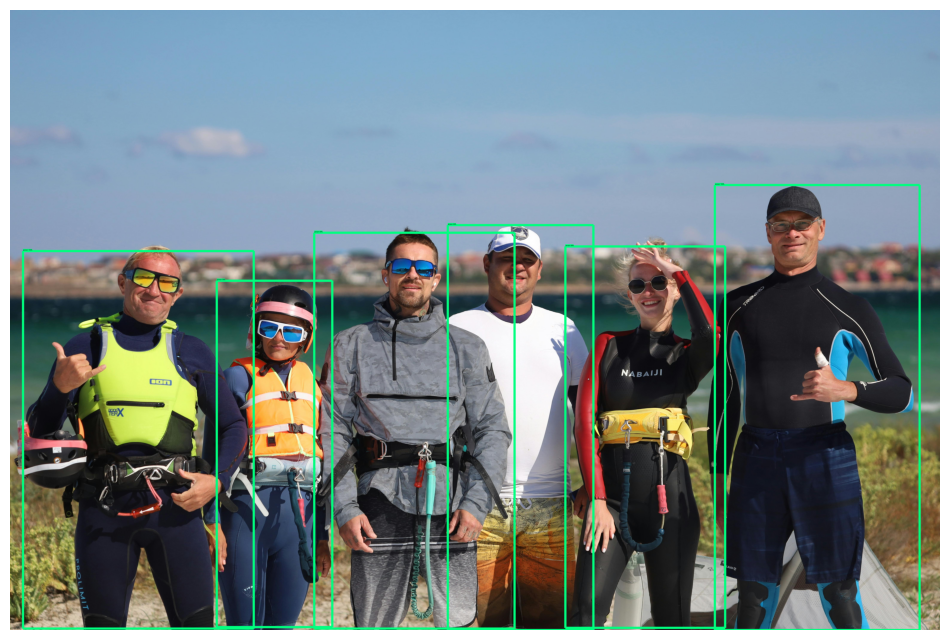

In [ ]:
# 7. Show image
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()